In [1]:
# 1. Imports
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="notebook")

In [2]:
# 2. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# 3. Confirm root and subdirectories for UC Merced
ROOT_DIR = "/content/drive/MyDrive/Cross-Dataset Generalization Thesis"
UCM_DIR = os.path.join(ROOT_DIR, "uc_merced")

LOGS_DIR = os.path.join(UCM_DIR, "logs")
METRICS_DIR = os.path.join(UCM_DIR, "metrics")
MODELS_DIR = os.path.join(UCM_DIR, "models")
FIGS_DIR = os.path.join(UCM_DIR, "figs")

for d in [ROOT_DIR, UCM_DIR, LOGS_DIR, METRICS_DIR, MODELS_DIR, FIGS_DIR]:
    print(d, "exists:", os.path.exists(d))


/content/drive/MyDrive/Cross-Dataset Generalization Thesis exists: True
/content/drive/MyDrive/Cross-Dataset Generalization Thesis/uc_merced exists: True
/content/drive/MyDrive/Cross-Dataset Generalization Thesis/uc_merced/logs exists: True
/content/drive/MyDrive/Cross-Dataset Generalization Thesis/uc_merced/metrics exists: True
/content/drive/MyDrive/Cross-Dataset Generalization Thesis/uc_merced/models exists: True
/content/drive/MyDrive/Cross-Dataset Generalization Thesis/uc_merced/figs exists: True


In [4]:
# 4. Define model names and file patterns for UC Merced
models = {
    "ResNet50": {
        "history": "ucm_resnet50_history.csv",
        "history_ft": "ucm_resnet50_history_ft.csv",
        "metrics": "ucm_resnet50_test_metrics.json"
    },
    "DenseNet121": {
        "history": "ucm_densenet121_history.csv",
        "history_ft": "ucm_densenet121_history_ft.csv",
        "metrics": "ucm_densenet121_test_metrics.json"
    },
    "MobileNetV2": {
        "history": "ucm_mobilenetv2_history.csv",
        "history_ft": "ucm_mobilenetv2_history_ft.csv",
        "metrics": "ucm_mobilenetv2_test_metrics.json"
    },
    "EfficientNetB0": {
        "history": "ucm_efficientnetb0_history.csv",
        "history_ft": "ucm_efficientnetb0_history_ft.csv",
        "metrics": "ucm_efficientnetb0_test_metrics.json"
    }
}

histories = {}
metrics = {}

for name, files in models.items():
    # Load training logs (base + fine-tuning, if present)
    hist_path = os.path.join(LOGS_DIR, files["history"])
    df_hist = pd.read_csv(hist_path)
    hist_ft_path = os.path.join(LOGS_DIR, files["history_ft"])
    if os.path.exists(hist_ft_path):
        df_hist_ft = pd.read_csv(hist_ft_path)
        # Ensure epoch column is continuous
        if "epoch" in df_hist_ft.columns:
            df_hist_ft["epoch"] = df_hist["epoch"].max() + 1 + df_hist_ft["epoch"]
        histories[name] = pd.concat([df_hist, df_hist_ft], ignore_index=True)
    else:
        histories[name] = df_hist

    # Load test metrics JSON
    metrics_path = os.path.join(METRICS_DIR, files["metrics"])
    with open(metrics_path, "r") as f:
        m = json.load(f)
    metrics[name] = m

# Quick inspection
for name in models.keys():
    print(f"\n{name} history columns:", histories[name].columns.tolist())
    print(f"{name} test_accuracy:", metrics[name]["test_accuracy"])


ResNet50 history columns: ['epoch', 'accuracy', 'loss', 'val_accuracy', 'val_loss']
ResNet50 test_accuracy: 0.9476190209388733

DenseNet121 history columns: ['epoch', 'accuracy', 'loss', 'val_accuracy', 'val_loss']
DenseNet121 test_accuracy: 0.9452381134033203

MobileNetV2 history columns: ['epoch', 'accuracy', 'loss', 'val_accuracy', 'val_loss']
MobileNetV2 test_accuracy: 0.9166666865348816

EfficientNetB0 history columns: ['epoch', 'accuracy', 'loss', 'val_accuracy', 'val_loss']
EfficientNetB0 test_accuracy: 0.9404761791229248


In [5]:
# Assuming ROOT_DIR, MODELS_DIR, LOGS_DIR, FIGS_DIR, METRICS_DIR are already defined.
# If not, they would need to be defined here or run earlier cells.
# For demonstration, let's redefine them based on the previous notebook state.
ROOT_DIR = "/content/drive/MyDrive/Cross-Dataset Generalization Thesis"
UC_MERCED_DIR = os.path.join(ROOT_DIR, "uc_merced")
MODELS_DIR = os.path.join(UC_MERCED_DIR, "models")
LOGS_DIR = os.path.join(UC_MERCED_DIR, "logs")
FIGS_DIR = os.path.join(UC_MERCED_DIR, "figs")
METRICS_DIR = os.path.join(UC_MERCED_DIR, "metrics")

print("\n--- Inspecting Project Directories ---")

print(f"\nContents of ROOT_DIR ({ROOT_DIR}):")
if os.path.exists(ROOT_DIR):
    for item in os.listdir(ROOT_DIR):
        print(f"  - {item}")
else:
    print("  ROOT_DIR does not exist.")

print(f"\nContents of MODELS_DIR ({MODELS_DIR}):")
if os.path.exists(MODELS_DIR):
    for item in os.listdir(MODELS_DIR):
        print(f"  - {item}")
else:
    print("  MODELS_DIR does not exist.")

print(f"\nContents of LOGS_DIR ({LOGS_DIR}):")
if os.path.exists(LOGS_DIR):
    for item in os.listdir(LOGS_DIR):
        print(f"  - {item}")
else:
    print("  LOGS_DIR does not exist.")

print(f"\nContents of FIGS_DIR ({FIGS_DIR}):")
if os.path.exists(FIGS_DIR):
    for item in os.listdir(FIGS_DIR):
        print(f"  - {item}")
else:
    print("  FIGS_DIR does not exist.")

print(f"\nContents of METRICS_DIR ({METRICS_DIR}):")
if os.path.exists(METRICS_DIR):
    for item in os.listdir(METRICS_DIR):
        print(f"  - {item}")
else:
    print("  METRICS_DIR does not exist.")



--- Inspecting Project Directories ---

Contents of ROOT_DIR (/content/drive/MyDrive/Cross-Dataset Generalization Thesis):
  - 21_cross_dataset_zero_shot.ipynb
  - 15_ucm_model_comparison.ipynb
  - uc_merced
  - Thesis Writing Works
  - cross_dataset_zero_shot
  - eurosat
  - few_shot
  - 31_few_shot_eurosat_to_ucm.ipynb
  - 32_few_shot_finetune_ucm_to_eurosat.ipynb
  - 33_core_few_shot_tables.ipynb
  - robustness
  - 05_eurosat_model_comparison.ipynb

Contents of MODELS_DIR (/content/drive/MyDrive/Cross-Dataset Generalization Thesis/uc_merced/models):
  - ucm_resnet50_best.weights.h5
  - ucm_mobilenetv2_full.keras
  - ucm_mobilenetv2_best.weights.h5
  - ucm_efficientnetb0_full.keras
  - ucm_efficientnetb0_best.weights.h5
  - ucm_densenet121_full.keras
  - ucm_densenet121_best.weights.h5
  - ucm_resnet50_full.keras

Contents of LOGS_DIR (/content/drive/MyDrive/Cross-Dataset Generalization Thesis/uc_merced/logs):
  - ucm_mobilenetv2_history_ft.csv
  - ucm_resnet50_history.csv
  - ucm_e

In [6]:
# 5. Build a summary table of final metrics (accuracy, macro F1, etc.)
summary_rows = []

for name, m in metrics.items():
    report = m["classification_report"]
    macro_f1 = report["macro avg"]["f1-score"]
    weighted_f1 = report["weighted avg"]["f1-score"]
    summary_rows.append({
        "model": name,
        "test_accuracy": m["test_accuracy"],
        "test_loss": m["test_loss"],
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,model,test_accuracy,test_loss,macro_f1,weighted_f1
0,ResNet50,0.947619,0.260879,0.946993,0.948037
1,DenseNet121,0.945238,0.210489,0.944572,0.945296
2,MobileNetV2,0.916667,0.285195,0.918823,0.916388
3,EfficientNetB0,0.940476,0.189534,0.936410,0.939801


In [7]:
comparison_rows = []

for name, m in metrics.items():
    report = m["classification_report"]
    comparison_rows.append({
        "model": name,
        "test_accuracy": m["test_accuracy"],
        "macro_precision": report["macro avg"]["precision"],
        "macro_recall": report["macro avg"]["recall"],
        "macro_f1": report["macro avg"]["f1-score"],
        "weighted_precision": report["weighted avg"]["precision"],
        "weighted_recall": report["weighted avg"]["recall"],
        "weighted_f1": report["weighted avg"]["f1-score"]
    })

comparison_df = pd.DataFrame(comparison_rows)
print("--- Model Performance Comparison ---")
comparison_df_styled = comparison_df.style.format({
    'test_accuracy': '{:.4f}',
    'macro_precision': '{:.4f}',
    'macro_recall': '{:.4f}',
    'macro_f1': '{:.4f}',
    'weighted_precision': '{:.4f}',
    'weighted_recall': '{:.4f}',
    'weighted_f1': '{:.4f}'
})
display(comparison_df_styled)

--- Model Performance Comparison ---


,model,test_accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,ResNet50,0.9476,0.9487,0.9486,0.9470,0.9516,0.9476,0.9480
1,DenseNet121,0.9452,0.9494,0.9470,0.9446,0.9524,0.9452,0.9453
2,MobileNetV2,0.9167,0.9232,0.9235,0.9188,0.9251,0.9167,0.9164
3,EfficientNetB0,0.9405,0.9385,0.9378,0.9364,0.9425,0.9405,0.9398


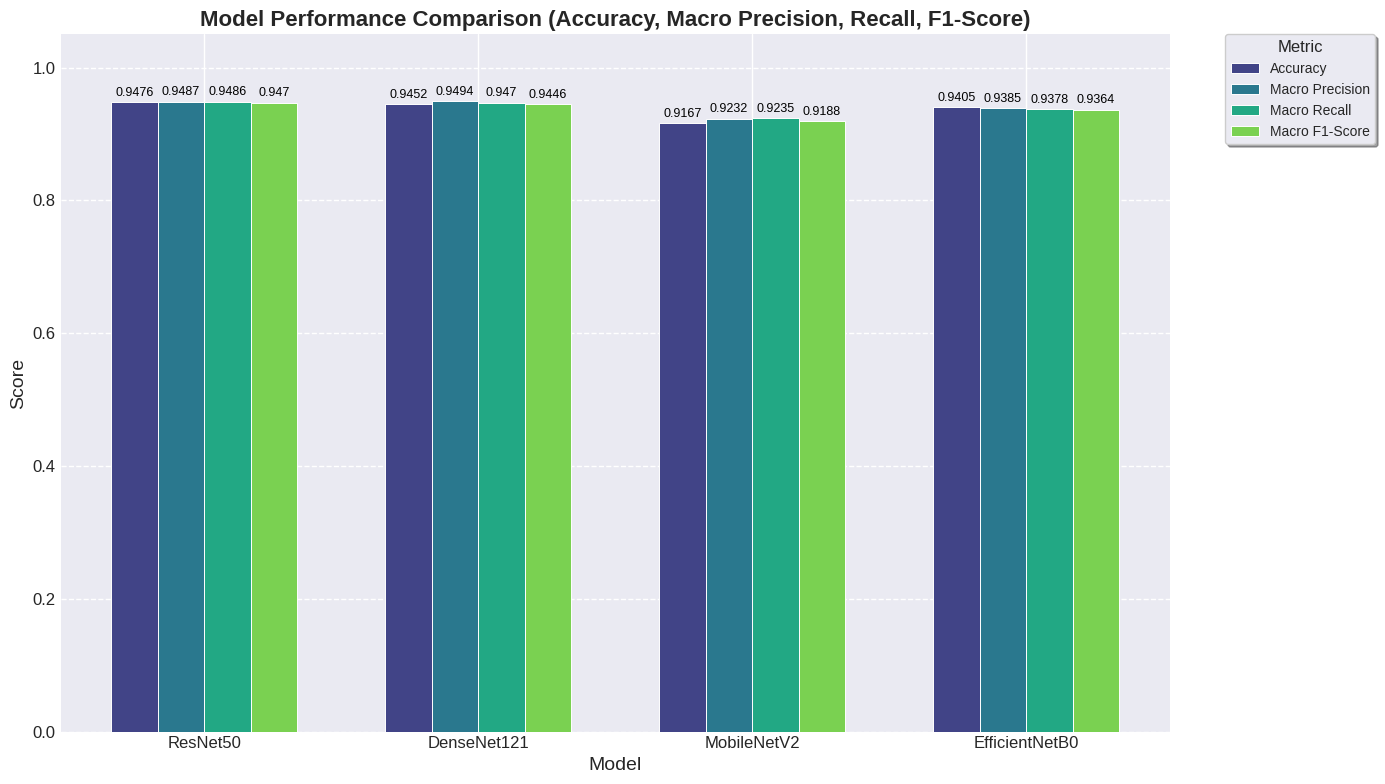

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Prepare data for plotting
model_names = comparison_df['model'].tolist()

metrics_to_plot = {
    'Accuracy': comparison_df['test_accuracy'].tolist(),
    'Macro Precision': comparison_df['macro_precision'].tolist(),
    'Macro Recall': comparison_df['macro_recall'].tolist(),
    'Macro F1-Score': comparison_df['macro_f1'].tolist()
}

# Set up the plot with a professional style
with plt.style.context('seaborn-v0_8-darkgrid'): # Using a clean, professional style
    fig, ax = plt.subplots(figsize=(14, 8))

    # Number of models and metrics
    n_models = len(model_names)
    n_metrics = len(metrics_to_plot)

    # Bar width and positions
    bar_width = 0.17
    index = np.arange(n_models)

    # Define a color palette for the metrics (changed to 'viridis')
    colors = sns.color_palette('viridis', n_colors=n_metrics)

    # Plotting each metric as a group of bars
    for i, (metric_name, metric_values) in enumerate(metrics_to_plot.items()):
        bars = ax.bar(index + i * bar_width, metric_values, bar_width, label=metric_name, color=colors[i], edgecolor='white', linewidth=0.7)

        # Add value labels on top of bars
        for bar in bars:
            yval = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, yval + 0.005, round(yval, 4), ha='center', va='bottom', fontsize=9, color='black')

    # Customize the plot
    ax.set_xlabel('Model', fontsize=14)
    ax.set_ylabel('Score', fontsize=14)
    ax.set_title('Model Performance Comparison (Accuracy, Macro Precision, Recall, F1-Score)', fontsize=16, fontweight='bold')

    ax.set_xticks(index + (n_metrics - 1) * bar_width / 2) # Center x-ticks under groups
    ax.set_xticklabels(model_names, rotation=0, ha='center', fontsize=12)
    #ax.legend(title='Metric', bbox_to_anchor=(1.05, 1), borderaxespad=0., fontsize=10, title_fontsize=12, loc='lower right', frameon=True, fancybox=True, shadow=True)
    plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=10, title_fontsize=12, frameon=True, fancybox=True, shadow=True) # Adjusted legend position

    ax.set_ylim(0, 1.05) # Set y-axis limit slightly above 1 for labels
    ax.tick_params(axis='y', labelsize=12)
    ax.grid(axis='y', linestyle='--', alpha=1.0)

    plt.tight_layout()
    plt.show()

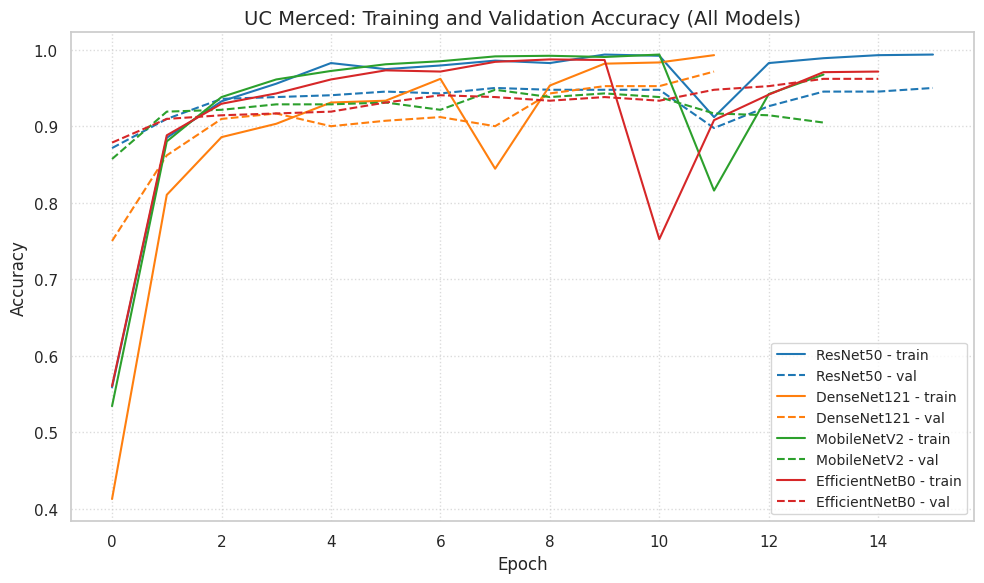

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define a consistent color palette for models
model_colors = {
    "ResNet50": "#1f77b4",       # Muted blue
    "DenseNet121": "#ff7f0e",    # Orange
    "MobileNetV2": "#2ca02c",    # Green
    "EfficientNetB0": "#d62728" # Red
}

plt.figure(figsize=(10, 6))

for name, df in histories.items():
    color = model_colors.get(name, "gray") # Get color for the model, default to gray if not found
    if "accuracy" in df.columns:
        plt.plot(df["epoch"], df["accuracy"], label=f"{name} - train", color=color, linestyle="-")
    if "val_accuracy" in df.columns:
        plt.plot(df["epoch"], df["val_accuracy"], label=f"{name} - val", color=color, linestyle="--")

plt.title("UC Merced: Training and Validation Accuracy (All Models)", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

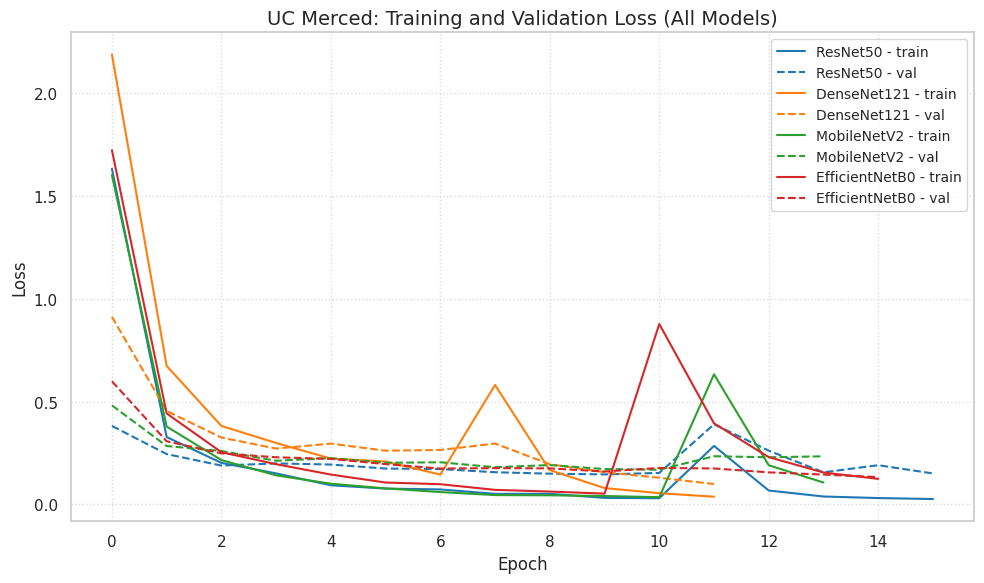

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define a consistent color palette for models (same as accuracy plot)
model_colors = {
    "ResNet50": "#1f77b4",       # Muted blue
    "DenseNet121": "#ff7f0e",    # Orange
    "MobileNetV2": "#2ca02c",    # Green
    "EfficientNetB0": "#d62728" # Red
}

plt.figure(figsize=(10, 6))

for name, df in histories.items():
    color = model_colors.get(name, "gray") # Get color for the model, default to gray if not found
    if "loss" in df.columns:
        plt.plot(df["epoch"], df["loss"], label=f"{name} - train", color=color, linestyle="-")
    if "val_loss" in df.columns:
        plt.plot(df["epoch"], df["val_loss"], label=f"{name} - val", color=color, linestyle="--")

plt.title("UC Merced: Training and Validation Loss (All Models)", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

In [11]:
# 9. Per-class F1-score comparison across models
# Build long-form DataFrame: one row per (model, class_name)
rows = []

# assume all classification_report dicts share the same class_names order as eurosat_class_mapping.json
for model_name, m in metrics.items():
    report = m["classification_report"]
    for cls in metrics[model_name]["classification_report"].keys():
        # skip aggregate rows
        if cls in ["accuracy", "macro avg", "weighted avg"]:
            continue
        cls_stats = report[cls]
        rows.append({
            "model": model_name,
            "class": cls,
            "precision": cls_stats["precision"],
            "recall": cls_stats["recall"],
            "f1": cls_stats["f1-score"],
            "support": cls_stats["support"],
        })

per_class_df = pd.DataFrame(rows)
per_class_df.head()

,model,class,precision,recall,f1,support
0,ResNet50,agricultural,1.000000,1.000000,1.000000,24.0
1,ResNet50,airplane,1.000000,1.000000,1.000000,19.0
2,ResNet50,baseballdiamond,1.000000,0.923077,0.960000,26.0
3,ResNet50,beach,1.000000,1.000000,1.000000,19.0
4,ResNet50,buildings,0.833333,0.882353,0.857143,17.0


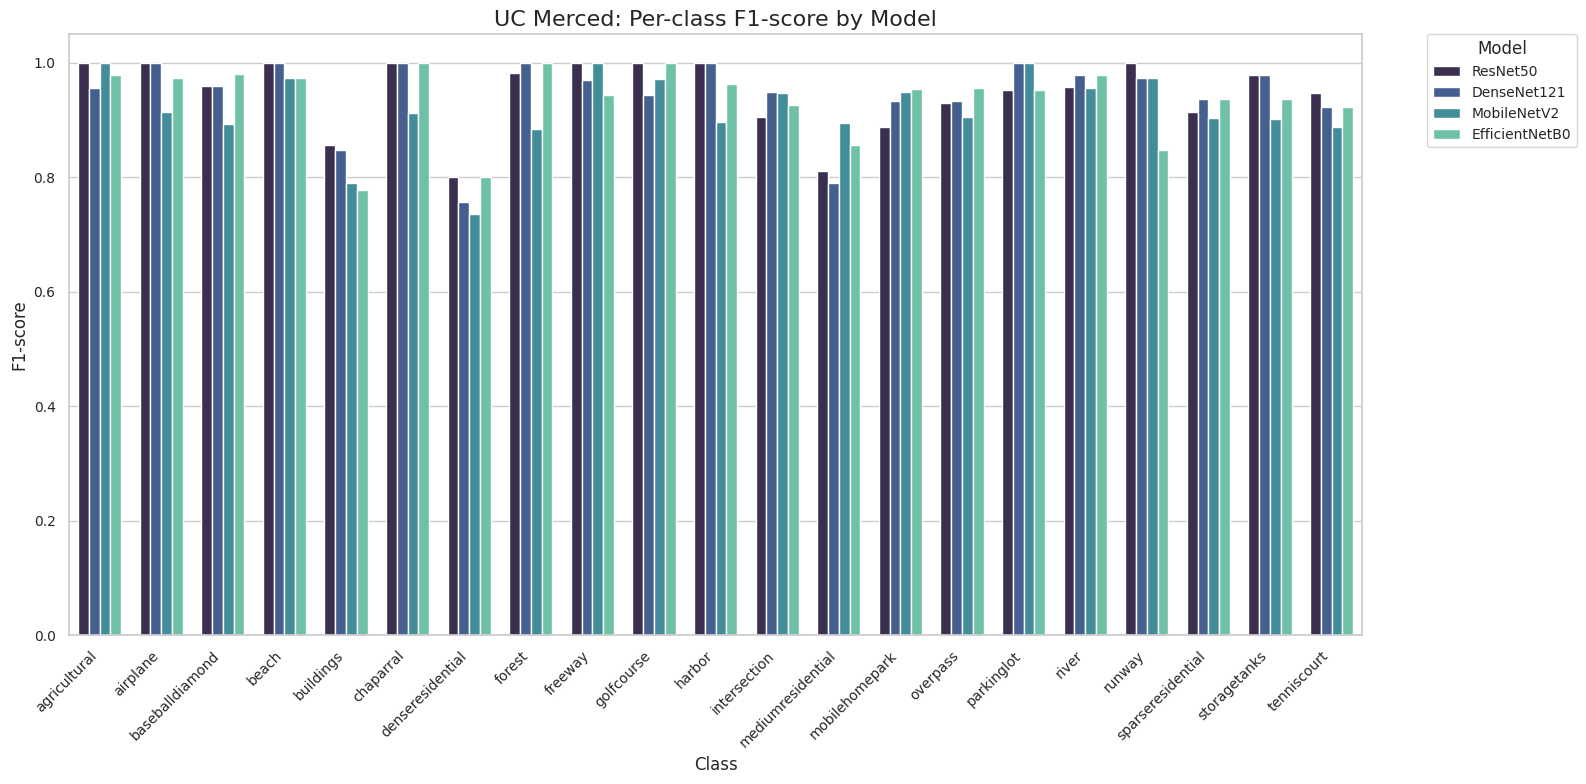

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 10. Plot per-class F1-score by model (grouped bars)
plt.figure(figsize=(16, 8)) # Increased figure size
sns.barplot(
    data=per_class_df,
    x="class",
    y="f1",
    hue="model",
    palette="mako", # Changed color palette to 'mako'
    width=0.7 # Made bars thinner
)
plt.title("UC Merced: Per-class F1-score by Model", fontsize=16) # Added font size to title
plt.xlabel("Class", fontsize=12)
plt.ylabel("F1-score", fontsize=12)
plt.xticks(rotation=45, ha="right", fontsize=10) # Adjusted font size for x-axis ticks and rotation
plt.yticks(fontsize=10) # Adjusted font size for y-axis ticks
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=10, title_fontsize=12) # Adjusted legend position
plt.tight_layout()
plt.show()

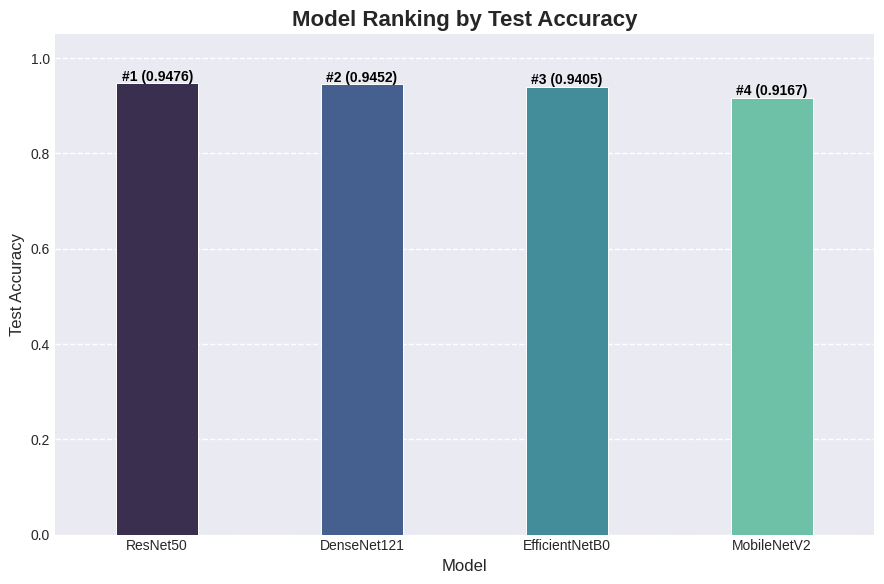

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the comparison_df by test_accuracy for ranking
summary_df_sorted = comparison_df.sort_values(by='test_accuracy', ascending=False).reset_index(drop=True)
summary_df_sorted['rank'] = summary_df_sorted.index + 1

# 10. Plot model ranking by test accuracy (with style from the second code)
with plt.style.context('seaborn-v0_8-darkgrid'): # Apply a professional style
    plt.figure(figsize=(9, 6))  # Increased figure size to match second code
    sns.barplot(
        x='model',
        y='test_accuracy',
        data=summary_df_sorted,
        hue='model',
        palette='mako',
        legend=False, # Remove legend from barplot call, we'll create a custom one if needed or rely on x-axis labels
        width=0.4, # Made bars thinner
        edgecolor='white', # Add white edge to bars
        linewidth=0.7 # Line width for the edge
    )

    # Add rank and accuracy labels on top of the bars
    for index, row in summary_df_sorted.iterrows():
        plt.text(index, row['test_accuracy'] + 0.005, f"#{row['rank']} ({row['test_accuracy']:.4f})",
                 color='black', ha="center", fontsize=10, fontweight='bold')

    plt.title('Model Ranking by Test Accuracy', fontsize=16, fontweight='bold')  # Added fontweight for consistency
    plt.xlabel('Model', fontsize=12)  # Adjusted fontsize to match second code
    plt.ylabel('Test Accuracy', fontsize=12)  # Adjusted fontsize to match second code
    plt.ylim(0, 1.05)  # Set y-axis limit slightly above 1 for labels
    plt.xticks(rotation=0, ha="center", fontsize=10)  # Changed rotation to 45 and ha="center"
    plt.yticks(fontsize=10)  # Adjusted fontsize to match second code
    plt.grid(axis='y', linestyle='--', alpha=1.0) # Add a horizontal grid for readability

    # Create a custom legend for model colors if desired, or remove if x-axis labels are sufficient
    # In this case, x-axis labels are the models, so a separate legend for hue might be redundant
    # If you still want it, you can create it manually, e.g., using matplotlib.patches.Patch
    # For now, relying on x-axis labels and bar labels.

    plt.tight_layout()
    plt.show()

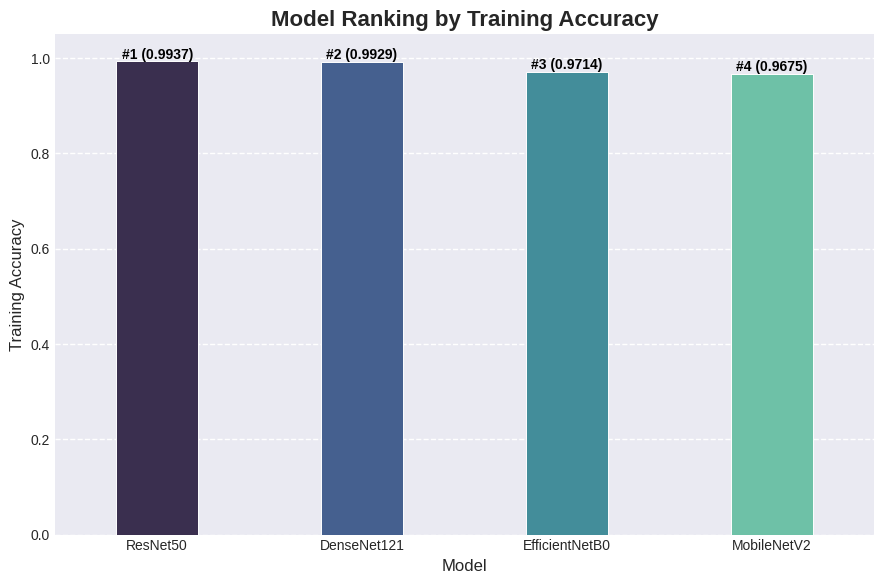

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the train_val_df by train_accuracy for ranking
train_accuracy_sorted_df = train_val_df.sort_values(by='train_accuracy', ascending=False).reset_index(drop=True)
train_accuracy_sorted_df['rank'] = train_accuracy_sorted_df.index + 1

# Plot model ranking by train accuracy
with plt.style.context('seaborn-v0_8-darkgrid'):
    plt.figure(figsize=(9, 6))
    sns.barplot(
        x='model',
        y='train_accuracy',
        data=train_accuracy_sorted_df,
        hue='model',
        palette='mako',
        legend=False,
        width=0.4,
        edgecolor='white',
        linewidth=0.7
    )

    # Add rank and accuracy labels on top of the bars
    for index, row in train_accuracy_sorted_df.iterrows():
        plt.text(index, row['train_accuracy'] + 0.005, f"#{row['rank']} ({row['train_accuracy']:.4f})",
                 color='black', ha="center", fontsize=10, fontweight='bold')

    plt.title('Model Ranking by Training Accuracy', fontsize=16, fontweight='bold')
    plt.xlabel('Model', fontsize=12)
    plt.ylabel('Training Accuracy', fontsize=12)
    plt.ylim(0, 1.05)
    plt.xticks(rotation=0, ha="center", fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=1.0)

    plt.tight_layout()
    plt.show()

In [14]:
# Build a summary metrics table: accuracy, loss, macro/weighted precision, recall, F1
summary_rows = []

for name, m in metrics.items():
    report = m["classification_report"]  # dict, as in the existing notebook
    macro = report["macro avg"]
    weighted = report["weighted avg"]

    summary_rows.append({
        "model": name,
        "test_accuracy": m["test_accuracy"],
        "test_loss": m["test_loss"],
        "macro_precision": macro["precision"],
        "macro_recall": macro["recall"],
        "macro_f1": macro["f1-score"],
        "weighted_precision": weighted["precision"],
        "weighted_recall": weighted["recall"],
        "weighted_f1": weighted["f1-score"],
    })

metrics_df = pd.DataFrame(summary_rows)
metrics_df = metrics_df.sort_values(by="test_accuracy", ascending=False).reset_index(drop=True)

display(metrics_df.style.format({
    "test_accuracy": "{:.4f}",
    "test_loss": "{:.4f}",
    "macro_precision": "{:.4f}",
    "macro_recall": "{:.4f}",
    "macro_f1": "{:.4f}",
    "weighted_precision": "{:.4f}",
    "weighted_recall": "{:.4f}",
    "weighted_f1": "{:.4f}",
}))


,model,test_accuracy,test_loss,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,ResNet50,0.9476,0.2609,0.9487,0.9486,0.9470,0.9516,0.9476,0.9480
1,DenseNet121,0.9452,0.2105,0.9494,0.9470,0.9446,0.9524,0.9452,0.9453
2,EfficientNetB0,0.9405,0.1895,0.9385,0.9378,0.9364,0.9425,0.9405,0.9398
3,MobileNetV2,0.9167,0.2852,0.9232,0.9235,0.9188,0.9251,0.9167,0.9164


In [15]:
# Final-epoch train/val accuracy/loss summary (like Table 4 in the paper)
train_val_rows = []

for name, df in histories.items():
    if not {"accuracy", "val_accuracy", "loss", "val_loss"}.issubset(df.columns):
        continue
    last = df.iloc[-1]
    train_val_rows.append({
        "model": name,
        "train_accuracy": last["accuracy"],
        "train_loss": last["loss"],
        "val_accuracy": last["val_accuracy"],
        "val_loss": last["val_loss"],
    })

train_val_df = pd.DataFrame(train_val_rows)
display(train_val_df.sort_values(by="val_accuracy", ascending=False).reset_index(drop=True).style.format(
    {"train_accuracy": "{:.4f}",
     "train_loss": "{:.4f}",
     "val_accuracy": "{:.4f}",
     "val_loss": "{:.4f}"}
))


,model,train_accuracy,train_loss,val_accuracy,val_loss
0,DenseNet121,0.9929,0.0380,0.9714,0.0997
1,EfficientNetB0,0.9714,0.1247,0.9619,0.1333
2,ResNet50,0.9937,0.0266,0.9500,0.1511
3,MobileNetV2,0.9675,0.1069,0.9048,0.2344
